<a href="https://colab.research.google.com/github/dymiyata/wva-ml-ai-2-2026-2027/blob/main/fashion_mnist.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [8]:
from tensorflow import keras
import matplotlib.pyplot as plt


In [9]:
(X_train, y_train), (X_test, y_test) = keras.datasets.fashion_mnist.load_data()

In [10]:
labels = [
    "T_shirt/top",
    "Trousers",
    "Pullover",
    "Dress",
    "Coat",
    "Sandal",
    "Shirt",
    "Sneaker",
    "Bag",
    "Ankle boot"
]

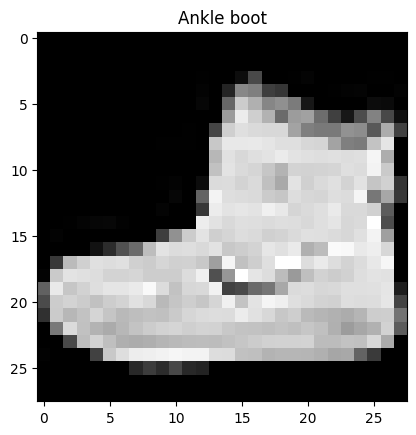

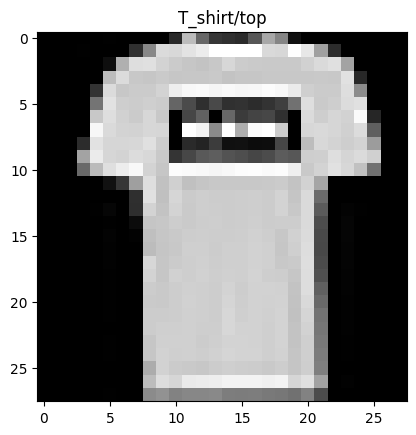

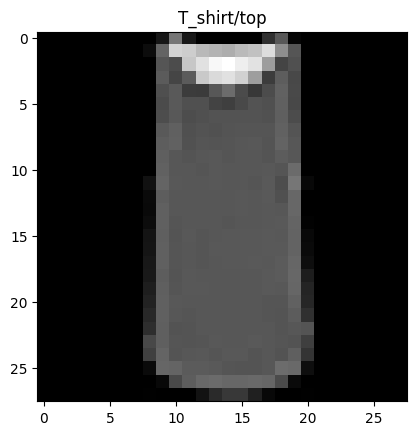

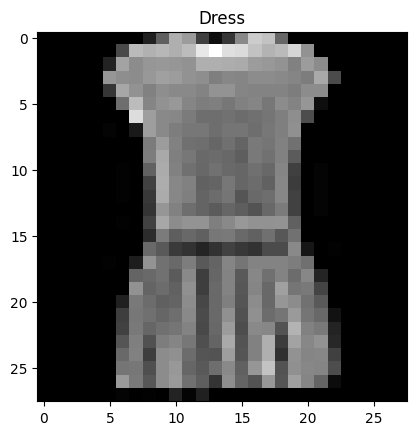

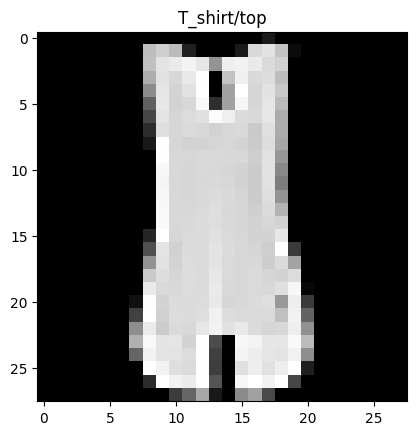

In [11]:
for i in range(5):
  plt.imshow(X_train[i], cmap="gray")
  plt.title(labels[y_train[i]])
  plt.show()

In [12]:
# Max pixel value is 255 so we scale so that values are between 0 and 1
X_train = X_train / 255.0
X_test = X_test / 255.0

X_train = X_train[..., None]
X_test = X_test[..., None]

In [13]:
model = keras.Sequential([
    keras.layers.Input(shape=(28,28,1)),
    keras.layers.Conv2D(16, (3,3), activation="relu"), # layer with 16 3x3 kernels
    keras.layers.MaxPooling2D((2,2)), # shrinks images via max pooling
    keras.layers.Conv2D(32, (3,3), activation="relu"), # layer with 16 3x3 kernels
    keras.layers.MaxPooling2D((2,2)), # shrinks images via max pooling
    keras.layers.Flatten(),
    keras.layers.Dense(64, activation="relu"),
    keras.layers.Dense(10, activation="softmax")
])

In [14]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [15]:
model.fit(X_train, y_train, epochs=6)

Epoch 1/6
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 34s 17ms/step - accuracy: 0.8145 - loss: 0.5158
Epoch 2/6
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 30s 16ms/step - accuracy: 0.8737 - loss: 0.3503
Epoch 3/6
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 41s 16ms/step - accuracy: 0.8891 - loss: 0.3041
Epoch 4/6
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 32s 17ms/step - accuracy: 0.8993 - loss: 0.2735
Epoch 5/6
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 30s 16ms/step - accuracy: 0.9086 - loss: 0.2503
Epoch 6/6
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 41s 16ms/step - accuracy: 0.9149 - loss: 0.2319


In [18]:

print(model.evaluate(X_train,y_train))
print(model.evaluate(X_test,y_test))

1875/1875 ━━━━━━━━━━━━━━━━━━━━ 12s 6ms/step - accuracy: 0.9117 - loss: 0.2308
[0.23076434433460236, 0.9117333292961121]
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.8910 - loss: 0.2975
[0.2975465953350067, 0.890999972820282]
